# PyTorch Siamese Networks

A Siamese network learns an embedding where images of the *same* person end up
close together and images of *different* people end up far apart -- trained
here on the Yale Face Database (15 subjects, 11 expressions each).

**Dataset fix:** the original download (`vision.ucsd.edu/datasets/yale_face_dataset_original/yalefaces.zip`)
is dead (404). This notebook pulls the identical file (same byte size,
6206308 bytes) from a GitHub mirror instead.

**No TensorFlow/Keras:** the course reuses `keras.preprocessing.image` purely
as an image-loading utility (`%tensorflow_version 2.x` is a Colab-only magic
and doesn't exist locally anyway). Since this is a PyTorch notebook, image
loading is done with PIL directly -- same result, one less dependency.

**Device:** uses `mps` (Apple GPU) with `cuda`/`cpu` fallback throughout,
in place of the course's `cuda`-only checks.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.utils import shuffle
from datetime import datetime
from glob import glob
from collections import Counter
from itertools import combinations
from PIL import Image
import os

Next we download the data. We're going to unzip it, and take a look at what
we have.

In [2]:
# data is from: http://vision.ucsd.edu/content/yale-face-database
# NOTE: the original UCSD download is dead. This mirror serves the identical
# file (verified: same 6206308-byte size as the original).
!wget -nc -O yalefaces.zip https://raw.githubusercontent.com/galvanom/FaceRecognition/master/yalefaces.zip

File ‘yalefaces.zip’ already there; not retrieving.


In [3]:
!unzip -n -q yalefaces.zip

In [4]:
files = glob('yalefaces/subject*')
len(files)

166

In [5]:
# easier to randomize later
np.random.shuffle(files)

In [6]:
# number of samples
N = len(files)
N

166

Next we define a helper to load an image and downsample it. The original
Yale faces images are quite large; we resize down to a fixed `(H, W)` so
every image array has the same shape.

In [7]:
H, W = 60, 80

def load_img(filepath):
  # load image and downsample, using PIL instead of keras.preprocessing.image
  img = Image.open(filepath).convert('RGB').resize((W, H))
  return np.array(img).astype('uint8')

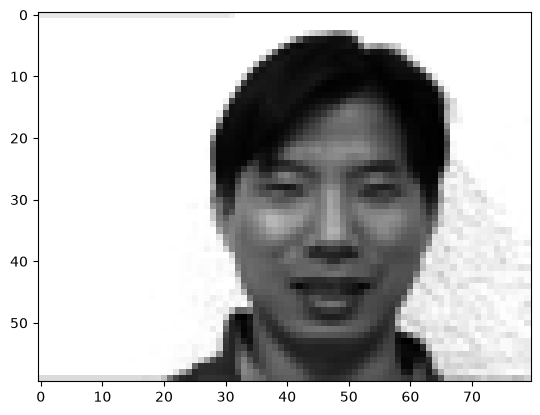

In [8]:
# look at an image for fun
img = load_img(np.random.choice(files))
plt.imshow(img)
plt.show()

In [9]:
img.shape

(60, 80, 3)

In [10]:
img.max()

np.uint8(255)

These images are actually grayscale, just stored with 3 identical channels
(that's what a plain RGB load of a grayscale image gives you) -- we can
confirm that below.

In [11]:
np.all(img[:,:,0] == img[:,:,1]), np.all(img[:,:,0] == img[:,:,2])

(np.True_, np.True_)

In [12]:
def to_grayscale(img):
  return img.mean(axis=-1)

On each iteration we load the image, convert it to grayscale, normalize it
to `(0, 1)`, and store it in our big array of images.

In [13]:
# load images as arrays
shape = (N, H, W)
images = np.zeros(shape)
for i, f in enumerate(files):
  img = to_grayscale(load_img(f)) / 255.
  images[i] = img

Next we make the labels. All the filenames are something like
`subject13.happy`, so we can parse out the subject number.

In [14]:
# make the labels
# all the filenames are something like 'subject13.happy'
labels = np.zeros(N)
for i, f in enumerate(files):
  filename = f.rsplit('/', 1)[-1]
  subject_num = filename.split('.', 1)[0]

  # subtract 1 since the filenames start from 1
  idx = int(subject_num.replace('subject', '')) - 1
  labels[i] = idx

I'm going to use the Counter object and pass in the labels, which has 12
images for the first subject and 11 for the rest (165 total, plus one extra
duplicate `.gif` in the original zip brings the file count to 166).

In [15]:
# how many of each subject do we have?
label_count = Counter(labels)
label_count

Counter({np.float64(0.0): 12,
         np.float64(11.0): 11,
         np.float64(12.0): 11,
         np.float64(13.0): 11,
         np.float64(6.0): 11,
         np.float64(10.0): 11,
         np.float64(5.0): 11,
         np.float64(8.0): 11,
         np.float64(2.0): 11,
         np.float64(9.0): 11,
         np.float64(3.0): 11,
         np.float64(7.0): 11,
         np.float64(4.0): 11,
         np.float64(1.0): 11,
         np.float64(14.0): 11})

In [16]:
# set of unique labels
unique_labels = set(label_count.keys())

In [17]:
# get the number of subjects
n_subjects = len(label_count)

Let's make it so 3 images for each subject are test data, and train will
just be N minus test.

In [18]:
# let's make it so 3 images for each subject are test data
# number of test points is then
n_test = 3 * n_subjects
n_train = N - n_test

In [19]:
# initialize arrays to hold train and test images
train_images = np.zeros([n_train] + list(img.shape))
train_labels = np.zeros(n_train)
test_images = np.zeros([n_test] + list(img.shape))
test_labels = np.zeros(n_test)

This is all just prep work that we need to do. We loop through the images
and labels together; for each subject, the first 3 images we see go to test,
and the rest go to train.

In [20]:
count_so_far = {}
train_idx = 0
test_idx = 0
for img, label in zip(images, labels):
  # increment the count
  count_so_far[label] = count_so_far.get(label, 0) + 1

  if count_so_far[label] > 3:
    # we have already added 3 test images for this subject
    # so add the rest to train
    train_images[train_idx] = img
    train_labels[train_idx] = label
    train_idx += 1

  else:
    # add the first 3 images to test
    test_images[test_idx] = img
    test_labels[test_idx] = label
    test_idx += 1

### What do we want to store?

We do **not** want to store pairs of images! Only their indexes.

Original data (per subject):

```
0: img 0 (subject 1)
1: img 1 (subject 1)
2: img 2 (subject 2)
3: img 3 (subject 2)
```

What we want to store -- pairs of *indices*, split into matches (same
subject) and non-matches (different subjects):

| Matches |  | Non-Matches |  |
|---|---|---|---|
| 0 | 1 | 0 | 2 |
| 2 | 3 | 0 | 3 |
|  |  | 1 | 2 |
|  |  | 1 | 3 |

We create a `label2idx` mapping for easy access, and then grab those images
later.

In [21]:
# create label2idx mapping for easy access
train_label2idx = {}
test_label2idx = {}

for i, label in enumerate(train_labels):
  if label not in train_label2idx:
    train_label2idx[label] = [i]
  else:
    train_label2idx[label].append(i)

for i, label in enumerate(test_labels):
  if label not in test_label2idx:
    test_label2idx[label] = [i]
  else:
    test_label2idx[label].append(i)

Now we build the actual positive (matching) and negative (non-matching)
pairs, as pairs of *indices* into `train_images` / `test_images`.

For positives: every combination of 2 images belonging to the same subject.
For negatives: every combination of 2 images belonging to different
subjects. There are far more possible negative pairs than positive pairs (any
two different subjects can be paired, vs. only images within one subject),
so we randomly subsample the negatives down to roughly the same count as the
positives -- otherwise the network would rarely see a positive example
during training.

In [22]:
def make_pairs(label2idx):
  positive_pairs = []
  negative_pairs = []

  labels_list = list(label2idx.keys())

  # positive pairs: all combinations of indices within the same label
  for label, indices in label2idx.items():
    positive_pairs += list(combinations(indices, 2))

  # negative pairs: all combinations of indices across different labels
  for label1, label2 in combinations(labels_list, 2):
    for idx1 in label2idx[label1]:
      for idx2 in label2idx[label2]:
        negative_pairs.append((idx1, idx2))

  # there are many more possible negative pairs than positive pairs,
  # so subsample the negatives down to the same size
  negative_pairs = shuffle(negative_pairs)[:len(positive_pairs)]

  return positive_pairs, negative_pairs

In [23]:
train_positives, train_negatives = make_pairs(train_label2idx)
test_positives, test_negatives = make_pairs(test_label2idx)

len(train_positives), len(train_negatives), len(test_positives), len(test_negatives)

(428, 428, 45, 45)

### The model

A small CNN embedding network. Both images in a pair are passed through the
*same* network (shared weights -- that's the "Siamese" part), producing two
embedding vectors, and we compute the Euclidean distance between them.
Matching pairs should end up with a small distance; non-matching pairs a
large one.

In [24]:
class CNN(nn.Module):
  def __init__(self, embedding_dim=50):
    super(CNN, self).__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(2),  # 60x80 -> 30x40

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(2),  # 30x40 -> 15x20

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(2),  # 15x20 -> 7x10 (floor division)
    )
    self.fc = nn.Linear(128 * 7 * 10, embedding_dim)

  def forward_once(self, x):
    out = self.conv(x)
    out = out.view(out.size(0), -1)
    out = self.fc(out)
    return out

  def forward(self, img1, img2):
    out1 = self.forward_once(img1)
    out2 = self.forward_once(img2)
    dist = F.pairwise_distance(out1, out2)
    return dist.flatten()

### Contrastive loss

The standard loss for Siamese networks: pulls matching pairs' distance
toward 0, and pushes non-matching pairs' distance to be at least `margin`
apart (and stops pushing once they're far enough, via the `clamp`).

In [25]:
class ContrastiveLoss(nn.Module):
  def __init__(self, margin=1.0):
    super(ContrastiveLoss, self).__init__()
    self.margin = margin

  def forward(self, distances, targets):
    # targets: 1 for a matching (positive) pair, 0 for non-matching
    pos_loss = targets * distances.pow(2)
    neg_loss = (1 - targets) * torch.clamp(self.margin - distances, min=0).pow(2)
    return torch.mean(pos_loss + neg_loss)

### Device

As in the other notebooks in this course, we prefer `mps` (Apple GPU) with a
`cuda`/`cpu` fallback, rather than the course's `cuda`-only check.

In [26]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)

mps


In [27]:
model = CNN()
model.to(device)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=8960, out_features=50, bias=True)
)

In [28]:
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters())

### `predict`

A small helper matching what `get_train_accuracy`/`get_test_accuracy` below
expect: given two batches of raw images (as numpy arrays), reshape them to
`(N, 1, H, W)`, move to `device`, run them through the model, and return the
distances as a flat numpy array.

In [29]:
def predict(x1, x2):
  x1 = torch.from_numpy(x1.astype(np.float32)).to(device)
  x2 = torch.from_numpy(x2.astype(np.float32)).to(device)
  with torch.no_grad():
    dist = model(x1, x2)
  return dist.cpu().numpy()

### Training loop

Each epoch, we shuffle the positive and negative pairs together, build
batches of image pairs (reshaped to `(N, 1, H, W)` for the CNN), and take one
gradient step per batch.

In [30]:
def get_batches(positives, negatives, images, batch_size=64):
  # combine positive (target=1) and negative (target=0) pairs, shuffled together
  all_pairs = [(i1, i2, 1) for i1, i2 in positives] + [(i1, i2, 0) for i1, i2 in negatives]
  all_pairs = shuffle(all_pairs)

  n_batches = int(np.ceil(len(all_pairs) / batch_size))
  for b in range(n_batches):
    batch = all_pairs[b * batch_size:(b + 1) * batch_size]
    n = len(batch)

    x_batch_1 = np.zeros((n, 1, H, W))
    x_batch_2 = np.zeros((n, 1, H, W))
    y_batch = np.zeros(n)

    for j, (idx1, idx2, target) in enumerate(batch):
      x_batch_1[j, 0] = images[idx1]
      x_batch_2[j, 0] = images[idx2]
      y_batch[j] = target

    yield x_batch_1, x_batch_2, y_batch

In [31]:
def train_one_epoch(epochs=1, batch_size=64):
  losses = []
  for epoch in range(epochs):
    epoch_losses = []
    for x1, x2, y in get_batches(train_positives, train_negatives, train_images, batch_size):
      x1 = torch.from_numpy(x1.astype(np.float32)).to(device)
      x2 = torch.from_numpy(x2.astype(np.float32)).to(device)
      y = torch.from_numpy(y.astype(np.float32)).to(device)

      optimizer.zero_grad()
      distances = model(x1, x2)
      loss = criterion(distances, y)
      loss.backward()
      optimizer.step()

      epoch_losses.append(loss.item())

    losses.append(np.mean(epoch_losses))
    print(f"epoch {epoch+1}/{epochs}, loss: {losses[-1]:.4f}")
  return losses

In [32]:
t0 = datetime.now()
losses = train_one_epoch(epochs=30, batch_size=64)
print("Training duration:", datetime.now() - t0)

epoch 1/30, loss: 13.8370
epoch 2/30, loss: 3.8945
epoch 3/30, loss: 1.1861
epoch 4/30, loss: 0.5072
epoch 5/30, loss: 0.2241
epoch 6/30, loss: 0.0942
epoch 7/30, loss: 0.0467
epoch 8/30, loss: 0.0252
epoch 9/30, loss: 0.0151
epoch 10/30, loss: 0.0107
epoch 11/30, loss: 0.0098
epoch 12/30, loss: 0.0082
epoch 13/30, loss: 0.0075
epoch 14/30, loss: 0.0068
epoch 15/30, loss: 0.0080
epoch 16/30, loss: 0.0056
epoch 17/30, loss: 0.0045
epoch 18/30, loss: 0.0043
epoch 19/30, loss: 0.0045
epoch 20/30, loss: 0.0037
epoch 21/30, loss: 0.0040
epoch 22/30, loss: 0.0059
epoch 23/30, loss: 0.0086
epoch 24/30, loss: 0.0078
epoch 25/30, loss: 0.0086
epoch 26/30, loss: 0.0140
epoch 27/30, loss: 0.0110
epoch 28/30, loss: 0.0159
epoch 29/30, loss: 0.0294
epoch 30/30, loss: 0.0213
Training duration: 0:00:59.474178


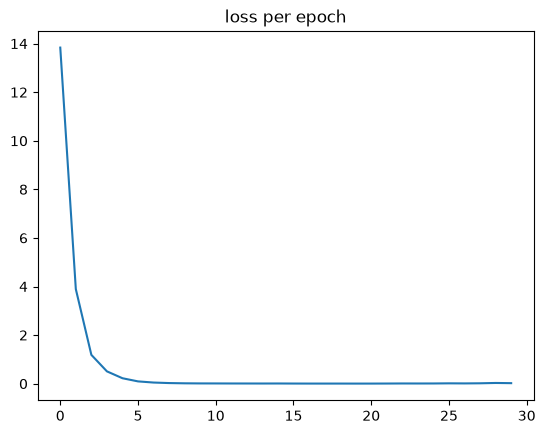

In [33]:
plt.plot(losses)
plt.title('loss per epoch')
plt.show()

### Accuracy

Since the dataset is imbalanced by construction (equal positives/negatives
here, but this pattern generalizes), we report `tp`, `tn`, `fp`, `fn`
directly rather than just accuracy.

In [34]:
# calculate accuracy before training
# since the dataset is imbalanced, we'll report tp, tn, fp, fn
def get_train_accuracy(threshold=0.85):
  positive_distances = []
  negative_distances = []

  tp = 0
  tn = 0
  fp = 0
  fn = 0

  batch_size = 64
  x_batch_1 = np.zeros((batch_size, 1, H, W))
  x_batch_2 = np.zeros((batch_size, 1, H, W))
  n_batches = int(np.ceil(len(train_positives) / batch_size))
  for i in range(n_batches):
    print(f"pos batch: {i+1}/{n_batches}")
    pos_batch_indices = train_positives[i * batch_size: (i + 1) * batch_size]

    # fill up x_batch and y_batch
    j = 0
    for idx1, idx2 in pos_batch_indices:
      x_batch_1[j,0] = train_images[idx1]
      x_batch_2[j,0] = train_images[idx2]
      j += 1

    x1 = x_batch_1[:j]
    x2 = x_batch_2[:j]
    distances = predict(x1, x2)
    positive_distances += distances.tolist()

    # update tp, tn, fp, fn
    tp += (distances < threshold).sum()
    fn += (distances > threshold).sum()

  n_batches = int(np.ceil(len(train_negatives) / batch_size))
  for i in range(n_batches):
    print(f"neg batch: {i+1}/{n_batches}")
    neg_batch_indices = train_negatives[i * batch_size: (i + 1) * batch_size]

    # fill up x_batch and y_batch
    j = 0
    for idx1, idx2 in neg_batch_indices:
      x_batch_1[j,0] = train_images[idx1]
      x_batch_2[j,0] = train_images[idx2]
      j += 1

    x1 = x_batch_1[:j]
    x2 = x_batch_2[:j]
    distances = predict(x1, x2)
    negative_distances += distances.tolist()

    # update tp, tn, fp, fn
    fp += (distances < threshold).sum()
    tn += (distances > threshold).sum()

  tpr = tp / (tp + fn)
  tnr = tn / (tn + fp)
  print(f"sensitivity (tpr): {tpr}, specificity (tnr): {tnr}")

  plt.hist(negative_distances, bins=20, density=True, label='negative_distances')
  plt.hist(positive_distances, bins=20, density=True, label='positive_distances')
  plt.legend()
  plt.show()

pos batch: 1/7
pos batch: 2/7
pos batch: 3/7
pos batch: 4/7
pos batch: 5/7
pos batch: 6/7
pos batch: 7/7
neg batch: 1/7
neg batch: 2/7
neg batch: 3/7
neg batch: 4/7
neg batch: 5/7
neg batch: 6/7
neg batch: 7/7
sensitivity (tpr): 0.9392523364485982, specificity (tnr): 1.0


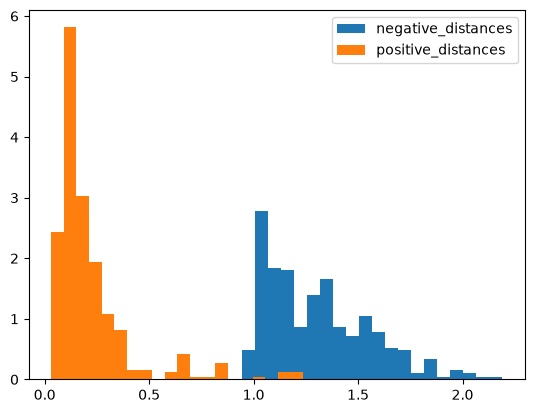

In [35]:
get_train_accuracy(0.65)

In [36]:
def get_test_accuracy(threshold=0.85):
  positive_distances = []
  negative_distances = []

  tp = 0
  tn = 0
  fp = 0
  fn = 0

  batch_size = 64
  x_batch_1 = np.zeros((batch_size, 1, H, W))
  x_batch_2 = np.zeros((batch_size, 1, H, W))
  n_batches = int(np.ceil(len(test_positives) / batch_size))
  for i in range(n_batches):
    print(f"pos batch: {i+1}/{n_batches}")
    pos_batch_indices = test_positives[i * batch_size: (i + 1) * batch_size]

    # fill up x_batch and y_batch
    j = 0
    for idx1, idx2 in pos_batch_indices:
      x_batch_1[j,0] = test_images[idx1]
      x_batch_2[j,0] = test_images[idx2]
      j += 1

    x1 = x_batch_1[:j]
    x2 = x_batch_2[:j]
    distances = predict(x1, x2)
    positive_distances += distances.tolist()

    # update tp, tn, fp, fn
    tp += (distances < threshold).sum()
    fn += (distances > threshold).sum()

  n_batches = int(np.ceil(len(test_negatives) / batch_size))
  for i in range(n_batches):
    print(f"neg batch: {i+1}/{n_batches}")
    neg_batch_indices = test_negatives[i * batch_size: (i + 1) * batch_size]

    # fill up x_batch and y_batch
    j = 0
    for idx1, idx2 in neg_batch_indices:
      x_batch_1[j,0] = test_images[idx1]
      x_batch_2[j,0] = test_images[idx2]
      j += 1

    x1 = x_batch_1[:j]
    x2 = x_batch_2[:j]
    distances = predict(x1, x2)
    negative_distances += distances.tolist()

    # update tp, tn, fp, fn
    fp += (distances < threshold).sum()
    tn += (distances > threshold).sum()

  tpr = tp / (tp + fn)
  tnr = tn / (tn + fp)
  print(f"sensitivity (tpr): {tpr}, specificity (tnr): {tnr}")

  plt.hist(negative_distances, bins=20, density=True, label='negative_distances')
  plt.hist(positive_distances, bins=20, density=True, label='positive_distances')
  plt.legend()
  plt.show()

pos batch: 1/1


neg batch: 1/1
sensitivity (tpr): 0.5777777777777777, specificity (tnr): 1.0


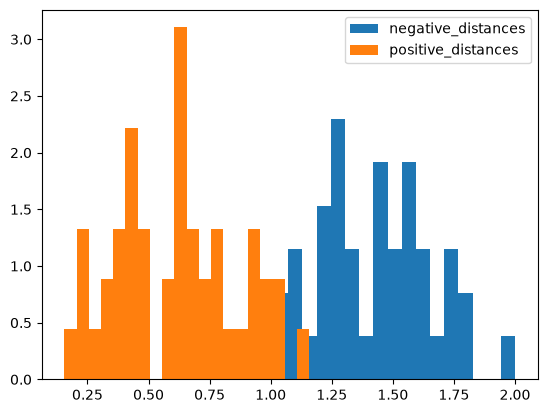

In [37]:
get_test_accuracy(0.65)

### What to expect

Train sensitivity/specificity should both be high (the network has seen these
exact pairs). Test performance will be lower -- these are subjects and pairs
the network never trained on directly -- but a working embedding should still
separate the two distance histograms reasonably well, with positive
(matching) distances clustered near 0 and negative (non-matching) distances
spread further out.